# Transformer on V-JEPA embeddings — binary NORM vs not-NORM on PTB-XL

In [1]:
import sys
from pathlib import Path

# Resolve the repo root from the notebook location and put `src` on sys.path
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'src').is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
print('Repo root:', REPO_ROOT)
print('Source dir on sys.path:', SRC_DIR)

Repo root: /Users/paolodeidda/Documents/UNI/Master/sem4/Comp Vision/CV_group_J
Source dir on sys.path: /Users/paolodeidda/Documents/UNI/Master/sem4/Comp Vision/CV_group_J/src


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

from transformer_vjepa.transformer_vjepa_binary import (
    ensure_ptbxl_metadata,
    load_clip_sequences,
    load_strat_fold_lookup,
    attach_strat_fold,
    split_sequences_by_strat_fold,
    TransformerVJEPABinary,
    train_model,
    evaluate_model,
    resolve_device,
)

device = resolve_device('auto')
print('Device:', device)

Device: mps


## 1. Load V-JEPA clip embeddings and split by PTB-XL strat_fold

In [3]:
CLIP_CACHE_DIR = REPO_ROOT / 'src' / 'data' / 'ptbxl_vjepa_clip_embedding_experiments' / 'records'
PTBXL_METADATA = REPO_ROOT / 'src' / 'data' / 'ptbxl' / 'ptbxl_database.csv'

assert CLIP_CACHE_DIR.is_dir(), (
    f'Missing clip embedding cache: {CLIP_CACHE_DIR}. '
)

# Downloads ptbxl_database.csv (~5 MB) from PhysioNet if missing.
PTBXL_METADATA = ensure_ptbxl_metadata(PTBXL_METADATA)

sequences = load_clip_sequences(CLIP_CACHE_DIR)
fold_lookup = load_strat_fold_lookup(PTBXL_METADATA)
sequences = attach_strat_fold(sequences, fold_lookup)
splits = split_sequences_by_strat_fold(sequences)

for split_name, items in splits.items():
    counts = {0: 0, 1: 0}
    for item in items:
        counts[item.label_id] = counts.get(item.label_id, 0) + 1
    print(f'{split_name}: {len(items)} sequences | label counts (NORM=0, not-NORM=1)={counts}')

if splits['train']:
    sample = splits['train'][0]
    print(f"\nExample sequence: record={sample.record_name} num_clips={sample.clip_embeddings.shape[0]} "
          f"embedding_dim={sample.clip_embeddings.shape[1]} label_id={sample.label_id} label_text={sample.label_text!r}")

train: 17418 sequences | label counts (NORM=0, not-NORM=1)={0: 7597, 1: 9821}
val: 2183 sequences | label counts (NORM=0, not-NORM=1)={0: 956, 1: 1227}
test: 2198 sequences | label counts (NORM=0, not-NORM=1)={0: 963, 1: 1235}

Example sequence: record=1 num_clips=6 embedding_dim=1024 label_id=0 label_text='normal rhythm'


## 2. Build the Transformer

Architecture: linear projection 1024->256, learnable [CLS] token, sinusoidal positional encoding, 4 TransformerEncoder layers (8 heads, FFN=1024, dropout 0.1), binary head Linear(256, 2). Padding mask supports variable-length clip sequences across the batch.

In [4]:
embedding_dim = int(splits['train'][0].clip_embeddings.shape[1])
model = TransformerVJEPABinary(
    embedding_dim=embedding_dim,
    model_dim=256,
    num_heads=8,
    num_layers=4,
    ffn_dim=1024,
    dropout=0.1,
    max_clips=32,
)
param_count = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {param_count / 1e6:.2f}M')

Model parameters: 3.42M


## 3. Train

AdamW + cosine annealing, gradient clipping at 1.0, class-balanced cross entropy, early stopping on validation F1 (patience 10).

In [5]:
model, history, best_state = train_model(
    model,
    splits['train'],
    splits['val'],
    device=device,
    batch_size=32,
    epochs=60,
    lr=1e-4,
    weight_decay=1e-4,
    patience=10,
    seed=42,
    verbose=True,
)
print(f"\nBest epoch: {history.best_epoch} (val F1 = {history.best_val_f1:.4f})")

epoch=001 train_loss=0.6974 val_loss=0.5958 val_f1=0.7537 val_acc=0.7036 val_auc=0.7679
epoch=002 train_loss=0.6096 val_loss=0.5512 val_f1=0.7272 val_acc=0.7178 val_auc=0.7913
epoch=003 train_loss=0.5837 val_loss=0.5773 val_f1=0.7684 val_acc=0.7082 val_auc=0.8068
epoch=004 train_loss=0.5846 val_loss=0.5259 val_f1=0.7621 val_acc=0.7435 val_auc=0.8158
epoch=005 train_loss=0.5595 val_loss=0.5330 val_f1=0.7777 val_acc=0.7389 val_auc=0.8207
epoch=006 train_loss=0.5637 val_loss=0.5239 val_f1=0.7349 val_acc=0.7306 val_auc=0.8225
epoch=007 train_loss=0.5526 val_loss=0.6146 val_f1=0.7699 val_acc=0.6935 val_auc=0.8209
epoch=008 train_loss=0.5493 val_loss=0.5100 val_f1=0.7567 val_acc=0.7448 val_auc=0.8269
epoch=009 train_loss=0.5557 val_loss=0.5844 val_f1=0.5823 val_acc=0.6583 val_auc=0.8306
epoch=010 train_loss=0.5488 val_loss=0.6813 val_f1=0.7771 val_acc=0.7096 val_auc=0.8300
epoch=011 train_loss=0.5411 val_loss=0.5016 val_f1=0.7678 val_acc=0.7554 val_auc=0.8345
epoch=012 train_loss=0.5303 val_

## 4. Evaluate (threshold tuned on fold 9, reported on fold 10)

In [6]:
test_metrics, threshold, val_metrics = evaluate_model(
    model,
    splits['val'],
    splits['test'],
    device=device,
    batch_size=32,
)

print(f"Tuned threshold (max val F1): {threshold:.3f}")
print(f"Val  : f1={val_metrics['f1']:.4f} acc={val_metrics['accuracy']:.4f} "
      f"precision={val_metrics['precision']:.4f} recall={val_metrics['recall']:.4f} "
      f"auc={(val_metrics['roc_auc'] or float('nan')):.4f}")
print(f"Test : f1={test_metrics['f1']:.4f} acc={test_metrics['accuracy']:.4f} "
      f"precision={test_metrics['precision']:.4f} recall={test_metrics['recall']:.4f} "
      f"auc={(test_metrics['roc_auc'] or float('nan')):.4f}")
print('Test confusion matrix [[TN, FP], [FN, TP]]:', test_metrics['confusion_matrix'])

Tuned threshold (max val F1): 0.450
Val  : f1=0.7795 acc=0.7325 precision=0.7262 recall=0.8411 auc=0.8207
Test : f1=0.7821 acc=0.7338 precision=0.7241 recall=0.8502 auc=0.8312
Test confusion matrix [[TN, FP], [FN, TP]]: [[563, 400], [185, 1050]]


## 5. Plots

Training curves, ROC on test, and the score histogram split by true label.

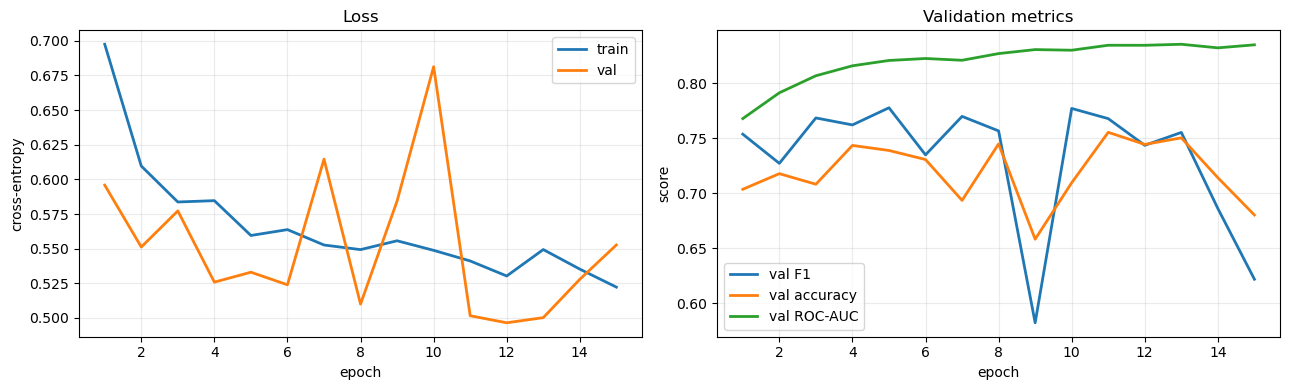

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.epochs, history.train_loss, label='train', lw=2)
axes[0].plot(history.epochs, history.val_loss, label='val', lw=2)
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('cross-entropy'); axes[0].set_title('Loss')
axes[0].grid(alpha=0.25); axes[0].legend()

axes[1].plot(history.epochs, history.val_f1, label='val F1', lw=2)
axes[1].plot(history.epochs, history.val_accuracy, label='val accuracy', lw=2)
axes[1].plot(history.epochs, history.val_roc_auc, label='val ROC-AUC', lw=2)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('score'); axes[1].set_title('Validation metrics')
axes[1].grid(alpha=0.25); axes[1].legend()
plt.tight_layout(); plt.show()

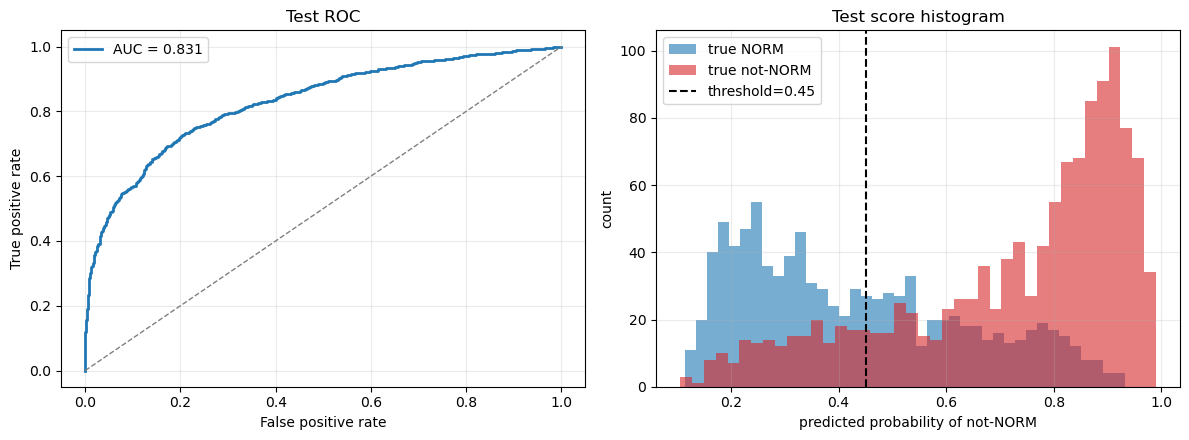

In [8]:
true_labels = np.asarray(test_metrics['true_labels'])
positive_scores = np.asarray(test_metrics['positive_scores'])
fpr, tpr, _ = roc_curve(true_labels, positive_scores)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {(test_metrics['roc_auc'] or float('nan')):.3f}")
axes[0].plot([0, 1], [0, 1], lw=1, ls='--', color='grey')
axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
axes[0].set_title('Test ROC'); axes[0].grid(alpha=0.25); axes[0].legend()

axes[1].hist(positive_scores[true_labels == 0], bins=40, alpha=0.6, label='true NORM', color='tab:blue')
axes[1].hist(positive_scores[true_labels == 1], bins=40, alpha=0.6, label='true not-NORM', color='tab:red')
axes[1].axvline(threshold, color='black', ls='--', lw=1.5, label=f'threshold={threshold:.2f}')
axes[1].set_xlabel('predicted probability of not-NORM'); axes[1].set_ylabel('count')
axes[1].set_title('Test score histogram'); axes[1].grid(alpha=0.25); axes[1].legend()
plt.tight_layout(); plt.show()

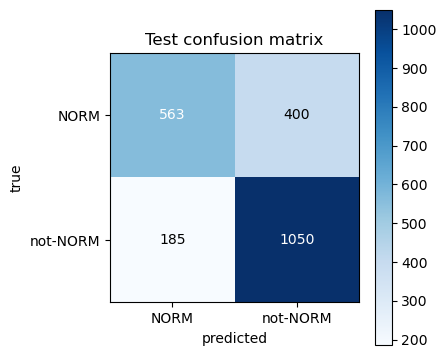

In [9]:
cm = np.asarray(test_metrics['confusion_matrix'])
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['NORM', 'not-NORM']); ax.set_yticklabels(['NORM', 'not-NORM'])
ax.set_xlabel('predicted'); ax.set_ylabel('true'); ax.set_title('Test confusion matrix')
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

## 6. Save artifacts

In [10]:
import json

OUT_DIR = REPO_ROOT / 'src' / 'data' / 'transformer_vjepa_binary'
OUT_DIR.mkdir(parents=True, exist_ok=True)

torch.save(best_state, OUT_DIR / 'model.pt')
np.savez(
    OUT_DIR / 'test_predictions.npz',
    record_names=np.asarray(test_metrics['record_names']),
    positive_scores=np.asarray(test_metrics['positive_scores']),
    true_labels=np.asarray(test_metrics['true_labels']),
)
summary = {
    'threshold': float(threshold),
    'val_metrics': {k: v for k, v in val_metrics.items() if not isinstance(v, list) or k == 'confusion_matrix'},
    'test_metrics': {k: v for k, v in test_metrics.items() if k not in {'positive_scores', 'true_labels', 'record_names'}},
    'best_epoch': history.best_epoch,
    'best_val_f1': history.best_val_f1,
    'history': {
        'epochs': history.epochs,
        'train_loss': history.train_loss,
        'val_loss': history.val_loss,
        'val_accuracy': history.val_accuracy,
        'val_f1': history.val_f1,
        'val_roc_auc': history.val_roc_auc,
    },
}
(OUT_DIR / 'summary.json').write_text(json.dumps(summary, indent=2))
print(f'Saved model, predictions and summary to {OUT_DIR}')

Saved model, predictions and summary to /Users/paolodeidda/Documents/UNI/Master/sem4/Comp Vision/CV_group_J/src/data/transformer_vjepa_binary
